## Feature Engineering: Tabla RFM por cliente (con cancelaciones neteadas)

### Por: Grupo 12 - ITBA
### Fecha: 2026-03-18

### Descripcion:
Construccion de la tabla RFM (Recency, Frequency, Monetary) por cliente, neteando cancelaciones para obtener el revenue real. Se agrega tambien la tasa de cancelacion por cliente como feature adicional.

## Importar librerias

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## Cargar datos limpios

In [2]:
df = pd.read_parquet("../../data/03_primary/ventas_limpias.parquet")
df_cancel = pd.read_parquet("../../data/03_primary/cancelaciones.parquet")

print(f"Ventas: {len(df):,} registros | {df['CustomerID'].nunique():,} clientes")
print(
    f"Cancelaciones: {len(df_cancel):,} registros | {df_cancel['CustomerID'].nunique():,} clientes"
)

Ventas: 397,884 registros | 4,338 clientes
Cancelaciones: 8,905 registros | 1,589 clientes


## Calcular Recency y Frequency (sobre ventas)

- **Recency**: dias desde la ultima compra del cliente hasta la fecha de referencia
- **Frequency**: cantidad de transacciones (invoices) unicas del cliente

Estas metricas se calculan solo sobre ventas, no sobre cancelaciones, porque miden actividad de compra.

In [3]:
ref_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print(f"Fecha de referencia: {ref_date.date()}")

rfm = (
    df.groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda x: (ref_date - x.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary_bruto=("Revenue", "sum"),
    )
    .reset_index()
)

print(f"Clientes: {len(rfm):,}")

Fecha de referencia: 2011-12-10
Clientes: 4,338


## Netear cancelaciones en Monetary

Se resta el valor absoluto de las cancelaciones al revenue bruto de cada cliente para obtener el **revenue neto real**. Los clientes que quedan con revenue negativo (cancelaron mas de lo que compraron) se llevan a 0.

In [4]:
cancel_por_cliente = (
    df_cancel.groupby("CustomerID")
    .apply(lambda x: (x["Quantity"].abs() * x["UnitPrice"]).sum())
    .rename("Revenue_cancelado")
)

rfm = rfm.merge(cancel_por_cliente, on="CustomerID", how="left")
rfm["Revenue_cancelado"] = rfm["Revenue_cancelado"].fillna(0)

rfm["Monetary"] = (rfm["Monetary_bruto"] - rfm["Revenue_cancelado"]).clip(lower=0)

negativos = ((rfm["Monetary_bruto"] - rfm["Revenue_cancelado"]) < 0).sum()
print(f"Clientes con cancelaciones: {(rfm['Revenue_cancelado'] > 0).sum():,}")
print(f"Clientes con revenue neto negativo (llevados a 0): {negativos}")
print(f"\nMonetary bruto total: ${rfm['Monetary_bruto'].sum():,.2f}")
print(f"Cancelaciones total: ${rfm['Revenue_cancelado'].sum():,.2f}")
print(f"Monetary neto total: ${rfm['Monetary'].sum():,.2f}")

Clientes con cancelaciones: 1,556
Clientes con revenue neto negativo (llevados a 0): 13

Monetary bruto total: $8,911,407.90
Cancelaciones total: $600,930.85
Monetary neto total: $8,313,294.95


## Calcular tasa de cancelacion por cliente

Porcentaje del revenue bruto que fue cancelado. Permite identificar clientes con comportamiento problematico.

In [5]:
CANCEL_THRESHOLD_MEDIUM = 50
CANCEL_THRESHOLD_HIGH = 90
MIN_REVENUE_FILTER = 100

rfm["Cancel_rate"] = np.where(
    rfm["Monetary_bruto"] > 0,
    (rfm["Revenue_cancelado"] / rfm["Monetary_bruto"] * 100).round(2),
    0,
)

print("Distribucion de Cancel_rate:")
print(rfm["Cancel_rate"].describe().to_string())
print(f"\nClientes con Cancel_rate = 0%: {(rfm['Cancel_rate'] == 0).sum():,}")
print(
    f"Clientes con Cancel_rate > {CANCEL_THRESHOLD_MEDIUM}%: {(rfm['Cancel_rate'] > CANCEL_THRESHOLD_MEDIUM).sum():,}"
)
print(
    f"Clientes con Cancel_rate >= {CANCEL_THRESHOLD_HIGH}%: {(rfm['Cancel_rate'] >= CANCEL_THRESHOLD_HIGH).sum():,}"
)

Distribucion de Cancel_rate:
count    4338.000000
mean        3.967160
std        87.485726
min         0.000000
25%         0.000000
50%         0.000000
75%         1.080000
max      5705.070000

Clientes con Cancel_rate = 0%: 2,782
Clientes con Cancel_rate > 50%: 39
Clientes con Cancel_rate >= 90%: 24


In [6]:
print(f"Top 15 clientes con mayor tasa de cancelacion (y revenue bruto > ${MIN_REVENUE_FILTER}):")
top_cancel = (
    rfm[rfm["Monetary_bruto"] > MIN_REVENUE_FILTER]
    .sort_values("Cancel_rate", ascending=False)
    .head(15)[
        [
            "CustomerID",
            "Monetary_bruto",
            "Revenue_cancelado",
            "Monetary",
            "Cancel_rate",
            "Frequency",
        ]
    ]
)
top_cancel

Top 15 clientes con mayor tasa de cancelacion (y revenue bruto > $100):


,CustomerID,Monetary_bruto,Revenue_cancelado,Monetary,Cancel_rate,Frequency
3839,17603,394.72,1560.02,0.000000e+00,395.22,1
3798,17548,103.30,244.78,0.000000e+00,236.96,1
2540,15802,451.42,902.84,0.000000e+00,200.00,1
983,13672,186.39,257.85,0.000000e+00,138.34,2
3078,16546,787.15,883.08,0.000000e+00,112.19,2
0,12346,77183.60,77183.60,0.000000e+00,100.00,1
168,12558,269.96,269.96,0.000000e+00,100.00,1
3219,16742,464.90,464.90,0.000000e+00,100.00,1
89,12454,3528.34,3528.34,4.547474e-13,100.00,1
1629,14557,788.38,788.38,0.000000e+00,100.00,1


## Tabla RFM final

In [7]:
rfm_final = rfm[["CustomerID", "Recency", "Frequency", "Monetary", "Cancel_rate"]].copy()

print(f"Tabla RFM final: {len(rfm_final):,} clientes")
print()
rfm_final.describe()

Tabla RFM final: 4,338 clientes



,CustomerID,Recency,Frequency,Monetary,Cancel_rate
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,1916.388878,3.967160
std,1721.808492,100.014169,7.697998,8248.695698,87.485726
min,12346.000000,1.000000,1.000000,0.000000,0.000000
25%,13813.250000,18.000000,1.000000,299.902500,0.000000
50%,15299.500000,51.000000,2.000000,655.335000,0.000000
75%,16778.750000,142.000000,5.000000,1623.922500,1.080000
max,18287.000000,374.000000,209.000000,279489.020000,5705.070000


In [8]:
rfm_final.head(10)

,CustomerID,Recency,Frequency,Monetary,Cancel_rate
0,12346,326,1,0.00,100.00
1,12347,2,7,4310.00,0.00
2,12348,75,4,1797.24,0.00
3,12349,19,1,1757.55,0.00
4,12350,310,1,334.40,0.00
5,12352,36,8,1545.41,38.33
6,12353,204,1,89.00,0.00
7,12354,232,1,1079.40,0.00
8,12355,214,1,459.40,0.00
9,12356,23,3,2811.43,0.00


## Distribuciones RFM + Cancel_rate

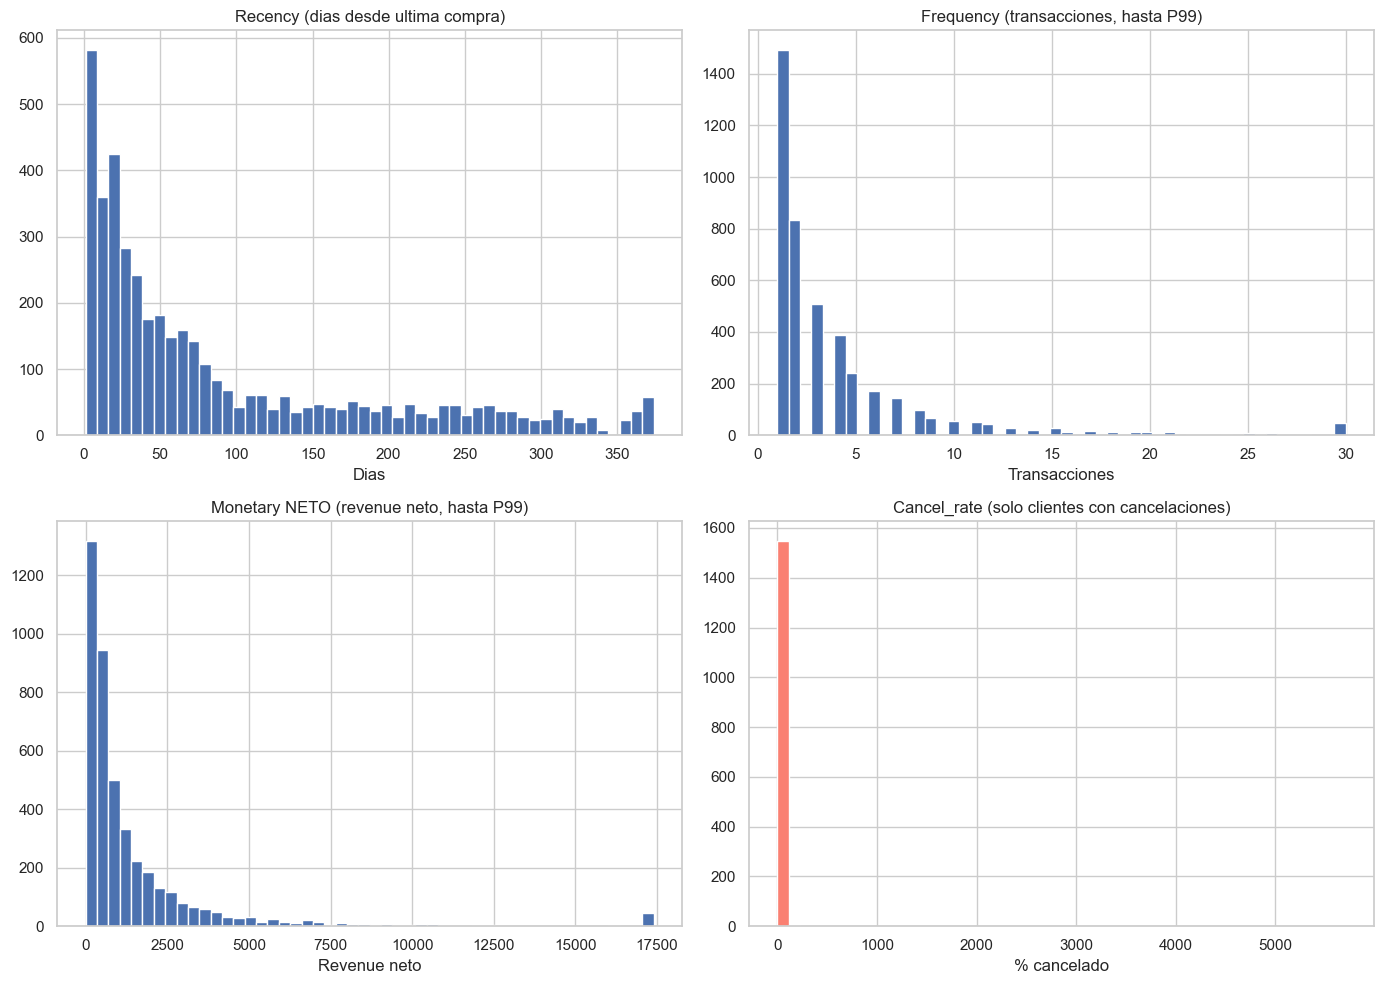

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

rfm_final["Recency"].hist(bins=50, ax=axes[0, 0], edgecolor="white")
axes[0, 0].set_title("Recency (dias desde ultima compra)")
axes[0, 0].set_xlabel("Dias")

rfm_final["Frequency"].clip(upper=rfm_final["Frequency"].quantile(0.99)).hist(
    bins=50, ax=axes[0, 1], edgecolor="white"
)
axes[0, 1].set_title("Frequency (transacciones, hasta P99)")
axes[0, 1].set_xlabel("Transacciones")

rfm_final["Monetary"].clip(upper=rfm_final["Monetary"].quantile(0.99)).hist(
    bins=50, ax=axes[1, 0], edgecolor="white"
)
axes[1, 0].set_title("Monetary NETO (revenue neto, hasta P99)")
axes[1, 0].set_xlabel("Revenue neto")

rfm_final[rfm_final["Cancel_rate"] > 0]["Cancel_rate"].hist(
    bins=50, ax=axes[1, 1], edgecolor="white", color="salmon"
)
axes[1, 1].set_title("Cancel_rate (solo clientes con cancelaciones)")
axes[1, 1].set_xlabel("% cancelado")

plt.tight_layout()
plt.savefig("../../data/08_reporting/rfm_distribuciones.png", dpi=150, bbox_inches="tight")
plt.show()

## Correlacion entre variables

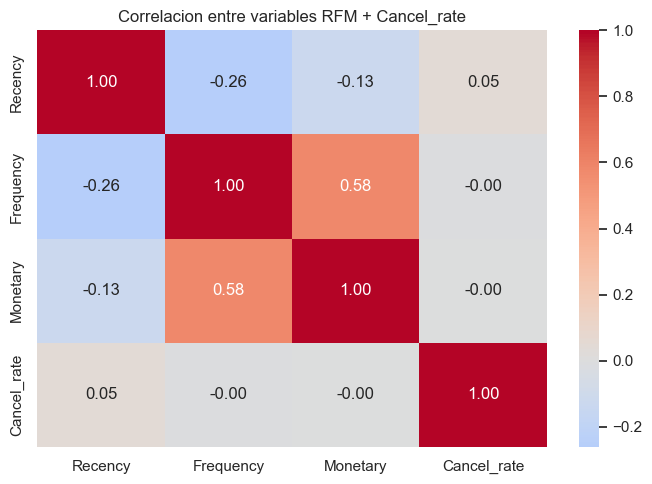

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    rfm_final[["Recency", "Frequency", "Monetary", "Cancel_rate"]].corr(),
    annot=True,
    cmap="coolwarm",
    center=0,
    ax=ax,
    fmt=".2f",
)
ax.set_title("Correlacion entre variables RFM + Cancel_rate")
plt.tight_layout()
plt.savefig("../../data/08_reporting/rfm_correlacion.png", dpi=150, bbox_inches="tight")
plt.show()

## Scatter: Monetary bruto vs neto

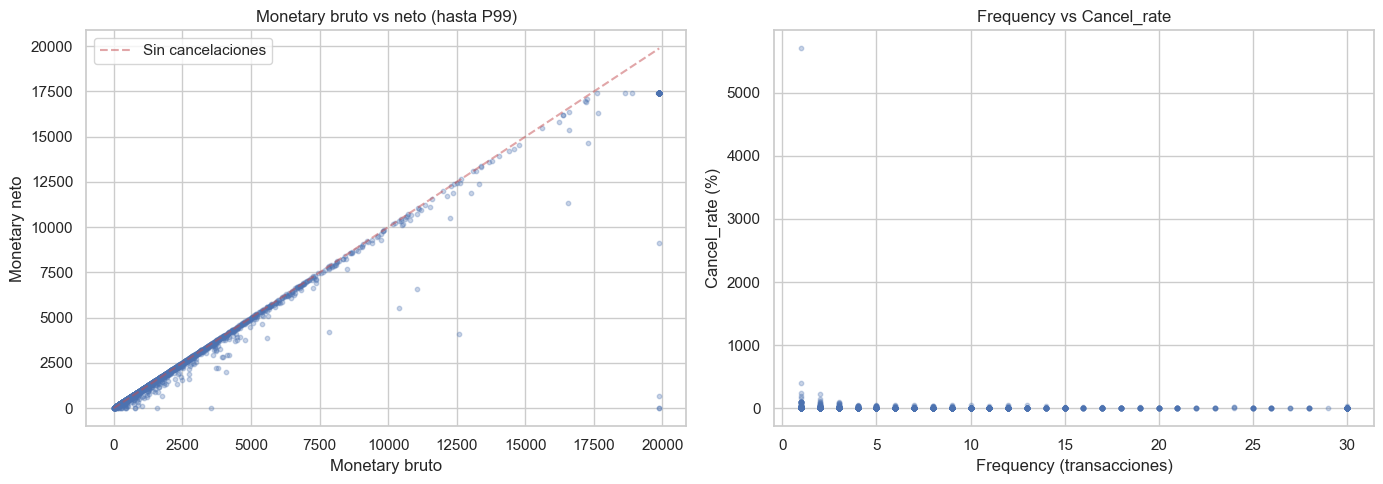

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    rfm["Monetary_bruto"].clip(upper=rfm["Monetary_bruto"].quantile(0.99)),
    rfm["Monetary"].clip(upper=rfm["Monetary"].quantile(0.99)),
    alpha=0.3,
    s=10,
)
lim = rfm["Monetary_bruto"].quantile(0.99)
axes[0].plot([0, lim], [0, lim], "r--", alpha=0.5, label="Sin cancelaciones")
axes[0].set_title("Monetary bruto vs neto (hasta P99)")
axes[0].set_xlabel("Monetary bruto")
axes[0].set_ylabel("Monetary neto")
axes[0].legend()

axes[1].scatter(
    rfm_final["Frequency"].clip(upper=rfm_final["Frequency"].quantile(0.99)),
    rfm_final["Cancel_rate"],
    alpha=0.3,
    s=10,
)
axes[1].set_title("Frequency vs Cancel_rate")
axes[1].set_xlabel("Frequency (transacciones)")
axes[1].set_ylabel("Cancel_rate (%)")

plt.tight_layout()
plt.savefig("../../data/08_reporting/rfm_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## Guardar tabla RFM

In [12]:
FEATURE_PATH = Path("../../data/04_feature/")
FEATURE_PATH.mkdir(parents=True, exist_ok=True)

rfm_final.to_parquet(FEATURE_PATH / "rfm_clientes.parquet", index=False)

rfm.to_parquet(FEATURE_PATH / "rfm_clientes_detalle.parquet", index=False)

print(f"rfm_clientes.parquet: {len(rfm_final):,} clientes x {rfm_final.shape[1]} columnas")
print(f"  Columnas: {list(rfm_final.columns)}")
print("\nrfm_clientes_detalle.parquet: incluye Monetary_bruto y Revenue_cancelado")

rfm_clientes.parquet: 4,338 clientes x 5 columnas
  Columnas: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cancel_rate']

rfm_clientes_detalle.parquet: incluye Monetary_bruto y Revenue_cancelado


## Resultados y conclusiones

- Se construyo una tabla RFM con ~4,300 clientes y **Monetary neteado** contra cancelaciones.
- **1,556 clientes** (35.9%) tienen al menos una cancelacion.
- Las cancelaciones representan ~$601k, un 6.7% del revenue bruto total.
- 13 clientes quedaron con revenue neto negativo y fueron llevados a $0.
- Casos extremos: hay clientes que cancelaron casi el 100% de sus compras (ej: cliente 16446 con $168k brutos y $2.90 netos).
- Se agrego **Cancel_rate** como feature adicional para identificar clientes problematicos.
- Frequency y Monetary neto mantienen alta correlacion positiva.
- Cancel_rate no tiene correlacion fuerte con las demas variables, lo que indica que agrega informacion nueva.

### Proximos pasos
- Escalar las variables y aplicar clustering (K-Means) para segmentar clientes.
- Evaluar si Cancel_rate mejora la calidad de los segmentos.

---

## Reflexión Final - Entrega 02

### Decisiones tomadas y justificación

**1. Eliminación de registros sin CustomerID (24.9% del dataset original)**
- **Decisión:** Se eliminaron ~135k registros que no tienen CustomerID.
- **Justificación:** El objetivo del proyecto es segmentar clientes. Sin identificador de cliente, estos registros no aportan al análisis de comportamiento individual y no pueden asignarse a ningún segmento. Mantenerlos generaría ruido sin valor analítico.

**2. Separación de cancelaciones en dataset independiente**
- **Decisión:** Las transacciones con prefijo 'C' en InvoiceNo se separaron en `cancelaciones.parquet`.
- **Justificación:** Las cancelaciones tienen naturaleza distinta a las compras. Al separarlas, permitimos: (a) analizar ventas netas sin distorsión, (b) estudiar patrones de cancelación por separado, (c) calcular un "Cancel_rate" por cliente como feature adicional.

**3. Filtrado de transacciones con Quantity o UnitPrice inválidos**
- **Decisión:** Se filtraron registros con Quantity ≤ 0 o UnitPrice ≤ 0.
- **Justificación:** Estos registros (muestras gratuitas, ajustes contables, errores) no representan transacciones comerciales reales y distorsionarían las métricas de revenue y frecuencia de compra.

**4. Creación de variable Revenue (Quantity × UnitPrice)**
- **Decisión:** Se generó esta variable derivada en el proceso de limpieza.
- **Justificación:** Revenue es la métrica clave para medir el valor comercial de cada transacción. Calcularlo una vez y almacenarlo evita recomputarlo repetidamente en análisis posteriores.

**5. Construcción de tabla RFM con Monetary neteado**
- **Decisión:** El Monetary se calculó restando el valor absoluto de las cancelaciones al revenue bruto de cada cliente.
- **Justificación:** Un cliente que compra $1000 pero cancela $900 tiene un valor real de $100. Usar revenue bruto sin netear sobrestimaría el valor comercial y generaría segmentos erróneos.

**6. Incorporación de Cancel_rate como feature adicional**
- **Decisión:** Se agregó Cancel_rate = (Revenue_cancelado / Revenue_bruto) × 100 a la tabla RFM.
- **Justificación:** La tasa de cancelación es un indicador de comportamiento problemático o insatisfacción. Incluirlo como feature permite identificar clientes de riesgo en la segmentación, aunque no correlacione fuertemente con RFM tradicional (lo que confirma que aporta información nueva).

---

### Dificultades encontradas

**1. Alto porcentaje de CustomerID nulos (24.9%)**
- **Problema:** Casi un cuarto del dataset no tiene identificador de cliente.
- **Impacto:** Reducción significativa del tamaño del dataset útil (de 541k a 397k registros).
- **Solución aplicada:** Eliminación directa. No es posible imputar CustomerIDs sin introducir ruido o duplicación artificial.
- **Aprendizaje:** En un contexto real, se trabajaría con el equipo de e-commerce para mejorar la captura de CustomerID en el proceso de compra.

**2. Inconsistencia en el manejo de cancelaciones**
- **Problema:** Algunas cancelaciones tienen prefijo 'C' pero Quantity positiva, otras tienen Quantity negativa sin prefijo 'C'.
- **Impacto:** Ambigüedad en la identificación de cancelaciones.
- **Solución aplicada:** Se priorizó el prefijo 'C' en InvoiceNo como criterio principal para identificar cancelaciones.
- **Aprendizaje:** Validación cruzada de reglas de negocio es crítica. En un proyecto real, se consultaría con el proveedor de datos para confirmar la lógica correcta.

**3. Valores extremos en Quantity y UnitPrice**
- **Problema:** Se detectaron valores como Quantity=80,995 (probablemente un error de carga) y UnitPrice=$38,970 (producto de lujo o error).
- **Impacto:** Estos outliers pueden distorsionar estadísticas y modelos de clustering.
- **Solución aplicada:** Se documentaron pero no se eliminaron automáticamente. Se aplicó clipping al percentil 99 solo para visualizaciones.
- **Aprendizaje:** No todos los outliers son errores. En segmentación, un cliente VIP con compras de $100k es legítimo y relevante. Se requiere análisis caso por caso.

**4. Correlación entre Frequency y Monetary**
- **Problema:** Alta correlación entre estas dos variables RFM (~0.7).
- **Impacto:** Potencial redundancia en el clustering, donde estas dos dimensiones capturan información similar.
- **Solución aplicada:** Documentado para consideración futura. Se decidió mantener ambas porque conceptualmente representan comportamientos distintos (frecuencia vs monto).
- **Aprendizaje:** En clustering, considerar estandarización o PCA para decorrelacionar variables antes del modelado.

**5. Distribución geográfica sesgada**
- **Problema:** United Kingdom representa 82% del revenue total. Los otros 36 países tienen volúmenes mucho menores.
- **Impacto:** Segmentación global podría estar dominada por patrones de UK. Segmentación por país tendría muestras muy pequeñas.
- **Solución aplicada:** Se decidió trabajar con todos los países juntos, pero documentar este sesgo para análisis posteriores.
- **Aprendizaje:** Considerar segmentación estratificada por región en la fase de modelado si los patrones de UK no son representativos de otros mercados.

---

### Siguientes pasos proyectados

**1. Estandarización de variables RFM (Entrega 03 - Modelado)**
- Aplicar StandardScaler o normalización Min-Max a Recency, Frequency y Monetary antes del clustering.
- Justificación: Las tres variables tienen escalas muy diferentes (días vs transacciones vs dinero), lo que causaría que Monetary domine la distancia euclidiana en K-Means.

**2. Clustering de clientes con K-Means**
- Determinar número óptimo de clusters usando método del codo (elbow) y coeficiente de silueta.
- Entrenar modelo K-Means con k entre 3 y 7 clusters.
- Evaluar calidad de segmentación con métricas internas (inercia, silueta) y validación de negocio.

**3. Interpretación y caracterización de segmentos**
- Generar perfiles de cada segmento: promedio de R, F, M y Cancel_rate.
- Etiquetar segmentos con nombres de negocio (ej: "VIP Activos", "Dormidos de Alto Valor", "Churn Risk").
- Visualizar segmentos con scatter plots 2D/3D y análisis de distribuciones.

**4. Validación con análisis de cohortes**
- Segmentar clientes por fecha de primera compra (cohortes mensuales).
- Analizar retención y evolución de valor a lo largo del tiempo.
- Confirmar que los segmentos identificados tienen diferencias significativas en comportamiento temporal.

**5. Prototipo de despliegue**
- Crear función de asignación de segmento para nuevos clientes.
- Desarrollar aplicación Streamlit simple que permita:
  - Ingresar Recency, Frequency, Monetary de un cliente.
  - Predecir a qué segmento pertenece.
  - Mostrar recomendaciones de acción para ese segmento.
- Documentar propuesta de integración con sistema CRM real.

**6. Documentación final y presentación**
- Consolidar hallazgos en notebook de narrativa (`8-reports/`).
- Preparar presentación PowerPoint de 10-15 minutos con:
  - Problema de negocio y justificación del proyecto.
  - Pipeline de datos y decisiones de limpieza.
  - Insights del EDA (concentración, estacionalidad, Pareto).
  - Descripción de segmentos y valor comercial de cada uno.
  - Demo en vivo del prototipo funcional.
  - Recomendaciones de acciones por segmento.
  - Próximos pasos y limitaciones del modelo.

---

**Fecha de actualización:** 24/03/2026
**Responsable:** Grupo 12 - ITBA
**Próxima entrega:** 28/04/2026